NameError: name 'mapa_formas' is not defined

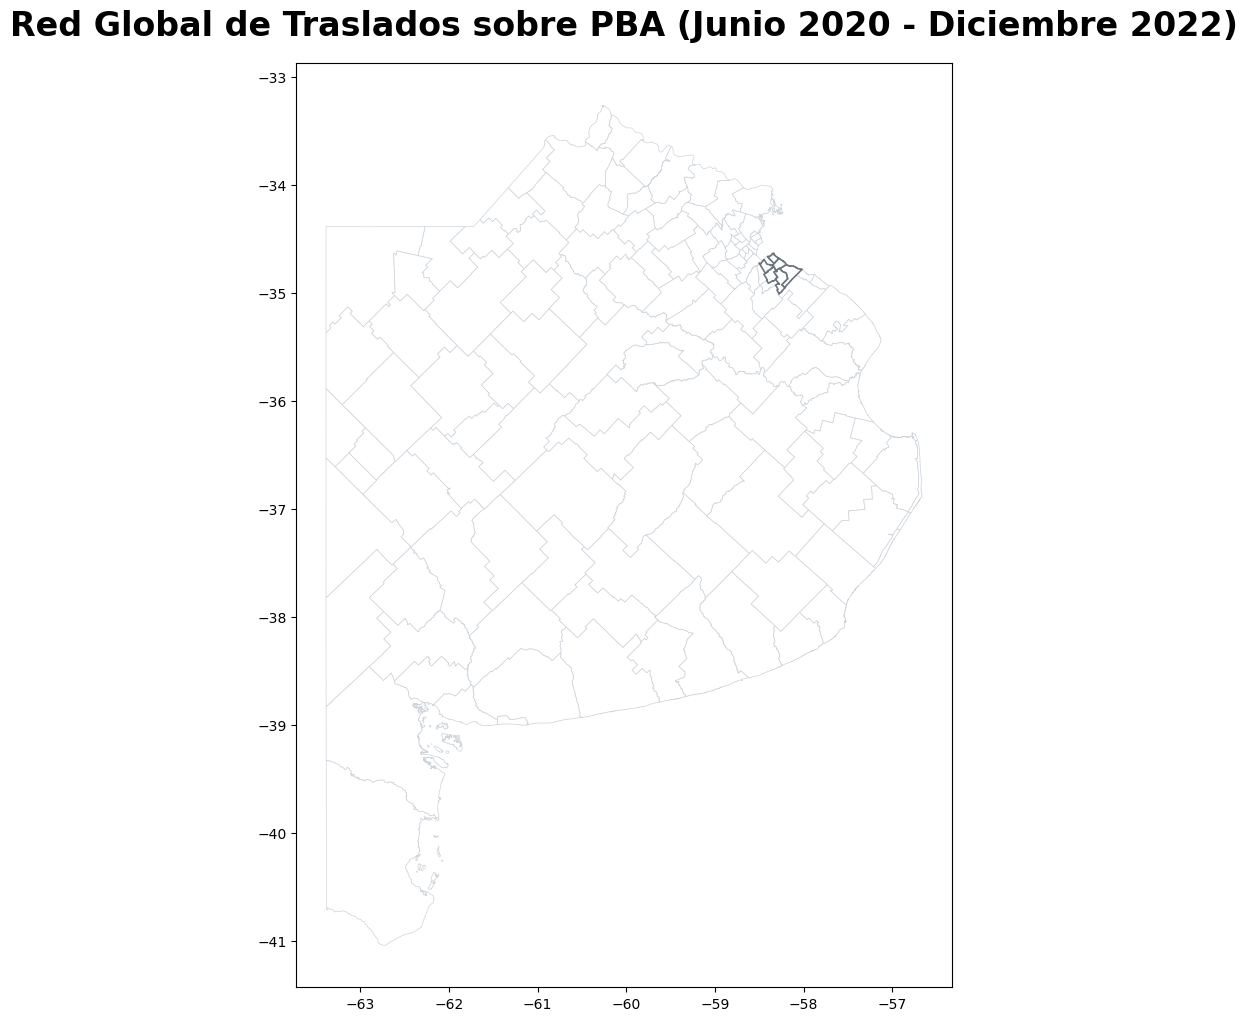

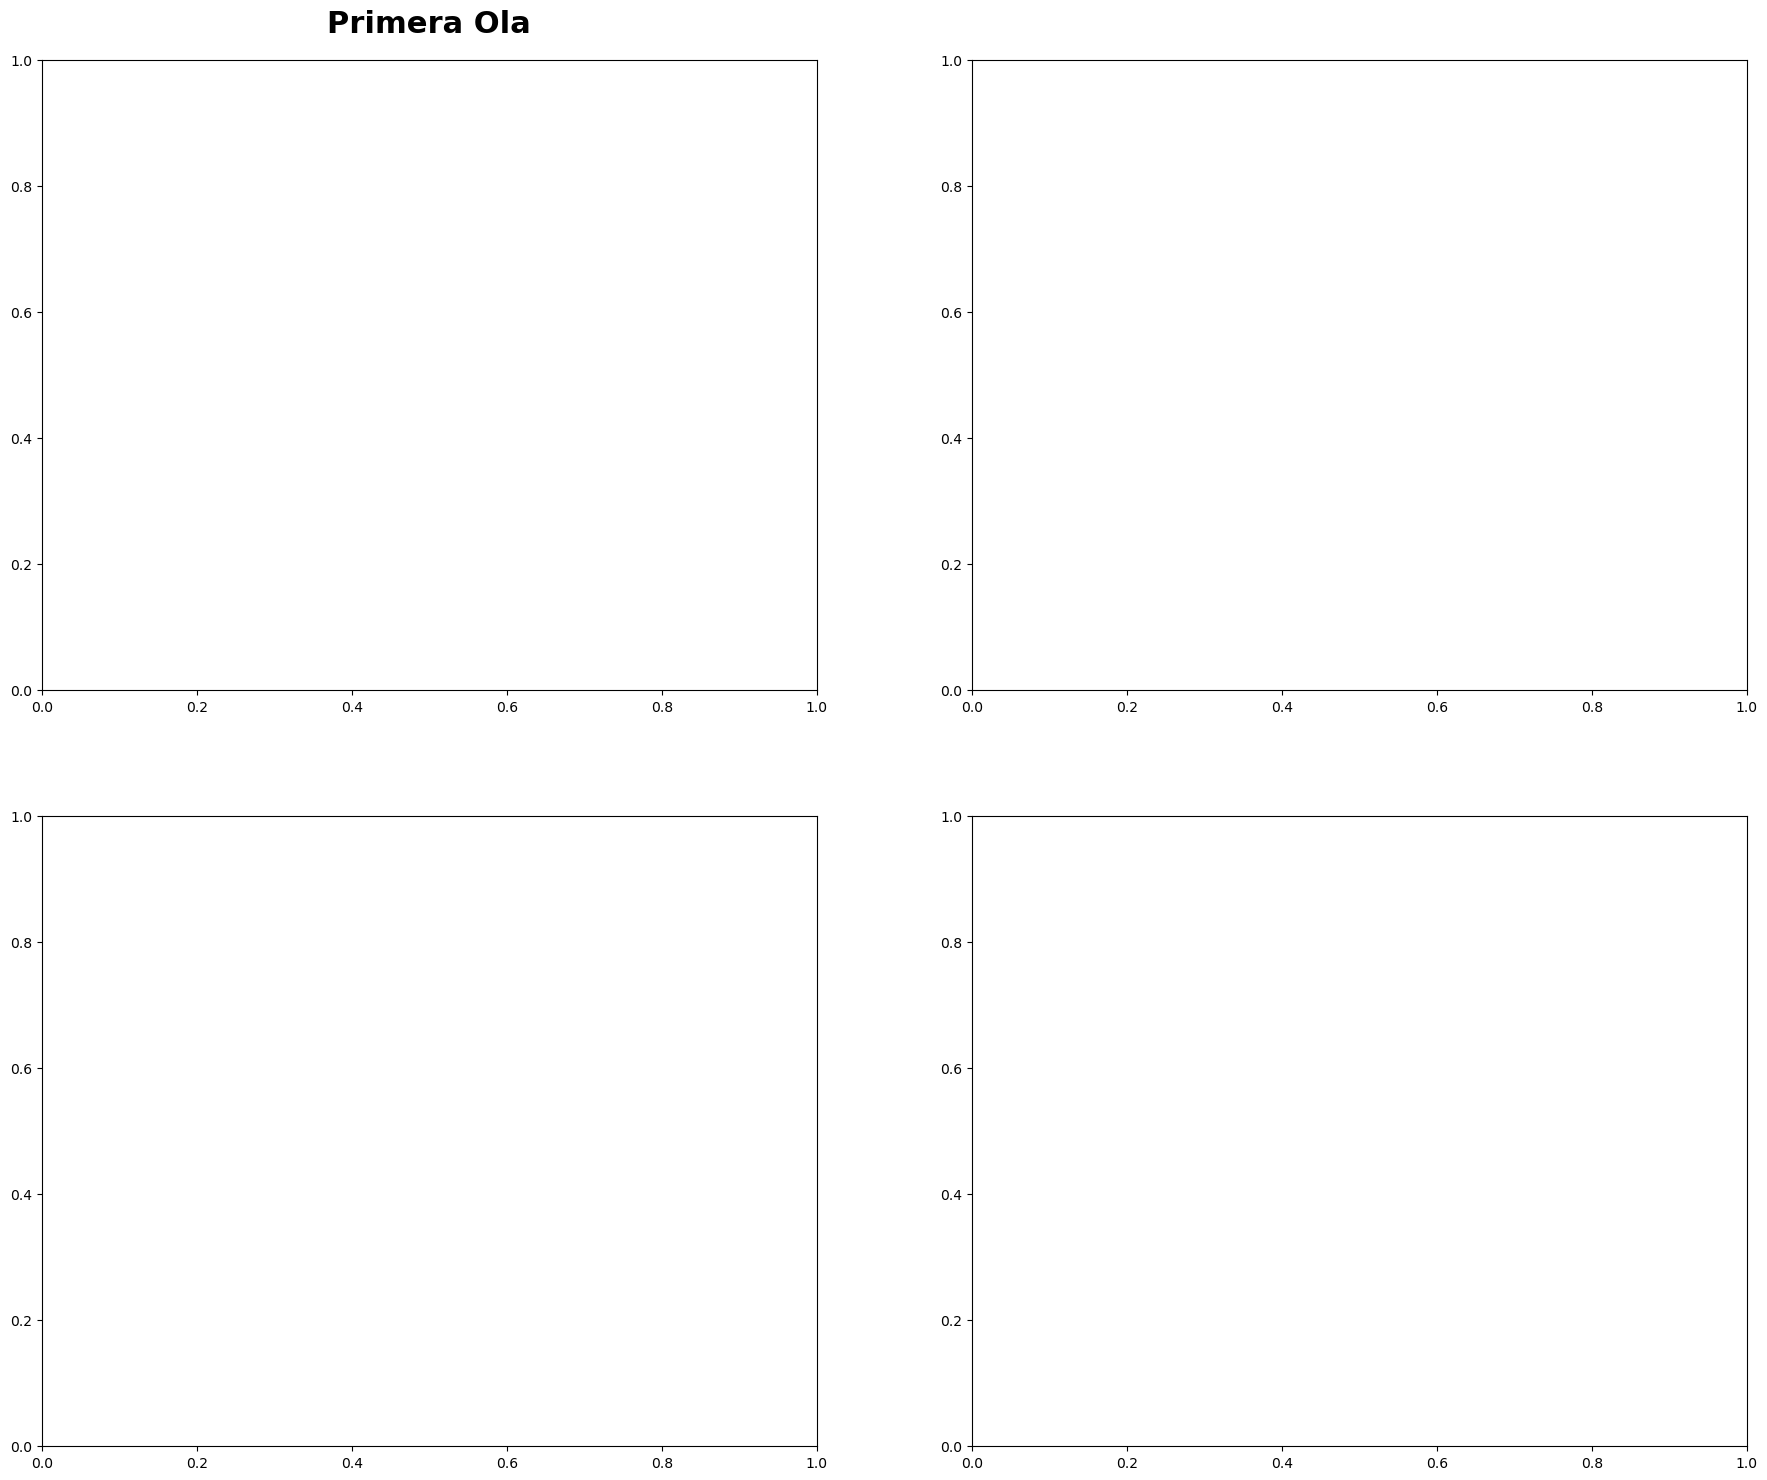

In [3]:
############################################################
# RED DE TRASLADOS HOSPITALARIOS - MAPA PBA
############################################################

import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


# ==========================================
# CONFIGURACIÓN TEMPORAL
# ==========================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]


# ==========================================================
# 1. CARGA DE DATOS Y LIMPIEZA INICIAL
# ==========================================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# Parseo de colores y formas para el mapa
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# Renombramiento de columnas para estandarizar
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',
    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo',
    'Edad': 'edad',
    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',
    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',
    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm',
    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',
    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

# Corrección de nomenclaturas
pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

# Estandarización de fechas y ordenamiento
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================================
# 2. CONSTRUCCIÓN DE TRASLADOS Y RUTAS
# ==========================================================

# Asociación del hospital y fechas de destino (usando la fila siguiente del mismo paciente)
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

# Cálculo de demoras de traslado
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' 
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

# Filtrado de traslados reales
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (
    pacientes['hospital_destino'].notna() & 
    pacientes['motivo_egreso'].isin(motivos_validos) & 
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)

df_potenciales = pacientes[mask_traslados].copy() 
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

# Alertas por demoras
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================================
# 3. CREACIÓN DEL DATAFRAME DE TRAYECTORIAS
# ==========================================================

dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
mapa_estados = {'criticas': 3, 'intermedias': 2, 'generales': 1}

def armar_trayectoria(group):
    """Reconstruye la ruta completa de cada paciente"""
    ruta_hosp = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    ruta_tipo = group['tipo_ingreso'].tolist() + [group['tipo_destino'].iloc[-1]]
    
    ruta_comp_num = [dict_complejidad.get(h, 0) for h in ruta_hosp] 
    ruta_tipo_num = [mapa_estados.get(str(e).lower().strip(), 0) for e in ruta_tipo]

    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales_str': " -> ".join(ruta_hosp),
        'ruta_tipos_str': " -> ".join([str(e) for e in ruta_tipo]),
        'ruta_tipos_num_str': " -> ".join([str(e) for e in ruta_tipo_num]),
        'ruta_complejidad_str': " -> ".join([str(c) for c in ruta_comp_num]),
        
        'ruta_hospitales_array': ruta_hosp,
        'ruta_tipos_array': ruta_tipo,
        'ruta_tipos_num_array': ruta_tipo_num,
        'ruta_complejidad_array': ruta_comp_num,
        
        'hospital_final': ruta_hosp[-1],
        'tipo_final_txt': ruta_tipo[-1],
        'tipo_final_num': ruta_tipo_num[-1],
        'complejidad_final': ruta_comp_num[-1],
        
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()


# ==========================================================
# 4. PREPARACIÓN DE COORDENADAS Y MAPA
# ==========================================================

df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
})

# Ajustes manuales para evitar cortes en los márgenes visuales
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Procesamiento de hospitales con coordenadas duplicadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []
for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if i > 0:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])


# ==========================================================
# 5. CÁLCULOS GLOBALES Y ESCALAS DE RENDERIZADO
# ==========================================================

# Constantes visuales
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 15.0

# Rango de tamaños visuales para los nodos
MIN_TAMANO_NODO = 50     
MAX_TAMANO_NODO = 2500    

# Cálculos de máximos y medianas para las aristas (traslados)
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
pesos_filtrados = agrupado_global[agrupado_global > 2]

if not pesos_filtrados.empty:
    min_t, med_t, max_t = int(pesos_filtrados.min()), int(np.median(pesos_filtrados)), int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

# CÁLCULO DINÁMICO DE INGRESOS (Evita errores de tipeo y lee directo de Pandas)
ingresos_globales = pacientes['hospital_origen'].value_counts()
# Convertimos a diccionario limpiando strings para asegurar que el matcheo no falle por un espacio
ingresos_reales_dict = {str(k).strip(): v for k, v in ingresos_globales.items()}
ingresos_reales = pd.Series(ingresos_reales_dict)

MAX_INGRESOS_GLOBAL = ingresos_reales.max() if not ingresos_reales.empty else 1
MIN_INGRESOS_GLOBAL = ingresos_reales.min() if not ingresos_reales.empty else 0

# Funciones de Escala
def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_node_size(ingreso):
    if MAX_INGRESOS_GLOBAL == MIN_INGRESOS_GLOBAL:
        return MIN_TAMANO_NODO
        
    # 1. Normalización Min-Max Lineal (de 0.0 a 1.0)
    escala_lineal = (ingreso - MIN_INGRESOS_GLOBAL) / (MAX_INGRESOS_GLOBAL - MIN_INGRESOS_GLOBAL)
    
    # 2. Exageración Cuadrática: Hace que los valores altos destaquen agresivamente 
    # frente a los medios. Si querés aún MÁS diferencia, cambialo a ** 3
    escala_exagerada = escala_lineal ** 2
    
    area = MIN_TAMANO_NODO + (escala_exagerada * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return area

def calc_legend_markersize(ingreso):
    """Convierte el área del nodo en el diámetro necesario para la leyenda"""
    area = calc_node_size(ingreso)
    return np.sqrt(area)


# ==========================================================
# 6. DIBUJO DEL MAPA DE FONDO Y RENDERIZADO DE LA RED
# ==========================================================

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')
ax.set_title('Red Global de Traslados sobre PBA (Junio 2020 - Diciembre 2022)', fontsize=24, fontweight='bold', pad=20)

# ---------------- A. Dibujo del Mapa Base (GeoPandas) ----------------
RUTA_MUNICIPIOS = "../data/shapefiles/departamento/departamentoPolygon.shp"
deptos = gpd.read_file(RUTA_MUNICIPIOS)

pba = deptos[deptos["in1"].astype(str).str.startswith("06")].copy()
pba["nam_limpio"] = (pba["nam"].astype(str).str.upper()
                     .str.replace('Á', 'A').str.replace('É', 'E')
                     .str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U'))

red_sudeste_names = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]
sudeste = pba[pba["nam_limpio"].isin(red_sudeste_names)].copy()

# Proyección a Lat/Lon para coincidir con las coordenadas de la red
pba = pba.to_crs(epsg=4326)
sudeste = sudeste.to_crs(epsg=4326)

pba.plot(ax=ax, color="#FFFFFF", edgecolor="#ced4da", linewidth=0.5, zorder=0)
sudeste.plot(ax=ax, color="#FFFFFF", edgecolor="#6c757d", linewidth=1.2, zorder=1)

# ---------------- B. Preparación del Grafo ----------------
# ... [AQUÍ VA TU CÓDIGO DE NETWORKX PARA ARMAR "G", agregando los nodos y ejes] ...






def asignar_color_tipo(nombre_hospital):
    nombre_norm = nombre_hospital.upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm:
        return '#d73027'  # Rojo
    elif 'UPA' in nombre_norm:
        return '#fdae61'  # Naranja
    else:
        return '#1a9850'  # Verde

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

# Para las leyendas finales, guardaremos los valores máximos encontrados en todos los periodos
v_max_encontrado = 0
i_max_encontrado = 0

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes_flat[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    # 1. FILTRADO
    mask_ingresos = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    ingresos_periodo_ser = pacientes[mask_ingresos]['hospital_origen'].value_counts()
    ingresos_por_hospital = ingresos_periodo_ser.to_dict()
    
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_periodo_traslados = df_traslados[mask_tras].copy()
    traslados_agrupados = df_periodo_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    
    # Traslados visibles (> 4)
    traslados_dibujables = traslados_agrupados[traslados_agrupados['peso'] > 2]
    
    # Actualizar máximos para la leyenda global
    if not traslados_dibujables.empty:
        v_max_encontrado = max(v_max_encontrado, traslados_dibujables['peso'].max())
    if not ingresos_periodo_ser.empty:
        i_max_encontrado = max(i_max_encontrado, ingresos_periodo_ser.max())

    G = nx.DiGraph()

# 2. AÑADIR NODOS
    for _, row in df_coordenadas.iterrows():
        h = row['hospital']
        n_ing = ingresos_por_hospital.get(h, 0)
        
        # Escala basada en el máximo del periodo actual
        escala_n = np.sqrt(n_ing) / np.sqrt(ingresos_periodo_ser.max()) if not ingresos_periodo_ser.empty and n_ing > 0 else 0
        tamano_nodo = MIN_TAMANO_NODO + (escala_n * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
        
        try: color_rgb = ast.literal_eval(str(row['color']))
        except: color_rgb = 'grey'
            
        forma_nodo = mapa_formas.get(row['shape'], 'o')
        
        # --- CAMBIO 1: Subimos el alpha de 0.05 a 0.4 para que los nodos inactivos se vean ---
        alpha_val = 0.9 if n_ing > 0 else 0.4
        
        G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

    # 3. AÑADIR ARISTAS
    for _, row_t in traslados_dibujables.iterrows():
        u, v = row_t['hospital_ingreso'], row_t['hospital_destino']
        if u in hospitales_conocidos and v in hospitales_conocidos:
            G.add_edge(u, v, weight=row_t['peso'])

    posiciones = nx.get_node_attributes(G, 'pos')
    
    # 4. DIBUJAR
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                               node_shape=forma, 
                               node_color=[G.nodes[n]['color'] for n in nodelist], 
                               node_size=[G.nodes[n]['size'] for n in nodelist], 
                               alpha=[G.nodes[n]['alpha'] for n in nodelist],
                               edgecolors='white', linewidths=0.5)

    for u, v, data in G.edges(data=True):
        peso = data['weight']
        escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

        color_flecha = asignar_color_tipo(u)
    
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 85 - 35) / 100.0
        if abs(rad_dinamico) < 0.12: rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                                width=grosor, edge_color=color_flecha, alpha=0.5,
                                arrowstyle='-|>', arrowsize=15, 
                                connectionstyle=f"arc3,rad={rad_dinamico}")

    # --- CAMBIO 2: Quitamos el "if" para que TODOS los nodos del mapa tengan su etiqueta ---
    labels = {n: n.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') 
              for n in G.nodes()}
    pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}
    
    # Le bajamos un poquito el color a las letras (#555555) para que no sature el mapa con tanto texto
    nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=10, font_color='#555555')

    ax.axis('off')
    












# INYECCIÓN A PRUEBA DE ERRORES: Leemos limpiando los strings para que NetworkX no pierda nodos
if 'G' in locals():
    for nodo in G.nodes():
        nombre_limpio = str(nodo).strip()
        cantidad_pacientes = ingresos_reales_dict.get(nombre_limpio, MIN_INGRESOS_GLOBAL)
        G.nodes[nodo]['size'] = calc_node_size(cantidad_pacientes)
    posiciones = nx.get_node_attributes(G, 'pos')

# ---------------- C. Renderizado Nodos y Aristas ----------------
if 'G' in locals():
    # Dibujo de Nodos
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nodos_dibujados = nx.draw_networkx_nodes(
            G, posiciones, nodelist=nodelist, ax=ax, 
            node_shape=forma, 
            node_color=[G.nodes[n]['color'] for n in nodelist], 
            node_size=[G.nodes[n]['size'] for n in nodelist], 
            alpha=[G.nodes[n]['alpha'] for n in nodelist],
            edgecolors='white', linewidths=1.0
        )
        if nodos_dibujados is not None:
            nodos_dibujados.set_zorder(4) 
            
    # Dibujo de Aristas (Traslados)
    for u, v, data in G.edges(data=True):
        peso = data['weight']
        # Nos aseguramos de tener una escala max de referencia
        max_peso_ref = MAX_TRASLADOS_GLOBAL if MAX_TRASLADOS_GLOBAL > 0 else 1
        escala_peso = np.sqrt(peso) / np.sqrt(max_peso_ref) 
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))
        
        # Color origen. Asumimos que la función existe en tu entorno
        try:
            color_flecha = asignar_color_original(u)
        except NameError:
            color_flecha = 'black' # Fallback
        
        # Curvatura dinámica para evitar superposiciones de aristas
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 90 - 35) / 100.0
        if abs(rad_dinamico) < 0.12:
            rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        aristas_dibujadas = nx.draw_networkx_edges(
            G, posiciones, edgelist=[(u, v)], ax=ax,
            width=grosor, edge_color=color_flecha, alpha=0.6,
            arrowstyle='-|>', arrowsize=20, 
            connectionstyle=f"arc3,rad={rad_dinamico}"
        )
        if aristas_dibujadas is not None:
            for flecha in aristas_dibujadas:
                flecha.set_zorder(3)

    # Dibujo de Etiquetas
    labels = {k: k.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') for k in G.nodes()}
    pos_labels = {k: (v[0], v[1] + 0.008) for k, v in posiciones.items() if k in labels} 

    textos_dibujados = nx.draw_networkx_labels(
        G, pos_labels, labels=labels, ax=ax, font_size=11,
        font_weight='bold', font_color='#333333', font_family='sans-serif',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
    for text_obj in textos_dibujados.values():
        text_obj.set_zorder(5)

# ---------------- D. Encuadre Final (Zoom) ----------------
minx, maxx = df_coordenadas['lon'].min(), df_coordenadas['lon'].max()
miny, maxy = df_coordenadas['lat'].min(), df_coordenadas['lat'].max()

margen_lon = (maxx - minx) * 0.15
margen_lat = (maxy - miny) * 0.15

ax.set_xlim(minx - margen_lon, maxx + margen_lon)
ax.set_ylim(miny - margen_lat, maxy + margen_lat)
ax.axis('off')


# ==========================================================
# 7. LEYENDAS (Sincronizadas y Limpias)
# ==========================================================

def redondear_estetico(valor):
    """Redondea los valores para que la leyenda muestre números limpios (10, 50, 100, etc)"""
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    if valor <= 500: return int(np.ceil(valor / 50) * 50)
    return int(np.ceil(valor / 100) * 100)

# Chequeamos si la variable existe para no romper (debe estar en el tramo de NetworkX)
if 'traslados_dibujables' in locals() and not traslados_dibujables.empty:
    v_max_g = redondear_estetico(traslados_dibujables['peso'].max())
    v_min_g = 5  
    v_med_g = redondear_estetico(v_max_g / 2)
else:
    v_min_g, v_med_g, v_max_g = 5, 10, 20

# Lectura limpia de la leyenda
i_max_g = redondear_estetico(MAX_INGRESOS_GLOBAL)
i_min_g = redondear_estetico(MIN_INGRESOS_GLOBAL) 
i_med_g = redondear_estetico((MAX_INGRESOS_GLOBAL + MIN_INGRESOS_GLOBAL) / 2)

# Construcción de Proxies Visuales para las Leyendas
proxies_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_g), label=f'{v_min_g}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_g)/2, label=f'{v_med_g/2}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_g)/2, label=f'{v_max_g/2}')
]

proxies_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

proxies_nodos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_legend_markersize(i_min_g), label=f'{i_min_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_legend_markersize(i_med_g), label=f'{i_med_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_legend_markersize(i_max_g), label=f'{i_max_g}')
]

# Renderizado de las 3 Leyendas
leg1 = ax.legend(handles=proxies_volumen, title="Traslados", 
                 loc='lower center', bbox_to_anchor=(0.40, 0.15), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg1)

leg2 = ax.legend(handles=proxies_colores, title="Origen del traslado", 
                 loc='lower center', bbox_to_anchor=(0.65, 0.15), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg2)

# Se aumenta fuertemente labelspacing y borderpad para que los nodos no se pisen
leg3 = ax.legend(handles=proxies_nodos, title="Ingresos", 
                 loc='lower right', bbox_to_anchor=(0.95, 0.15),  
                 frameon=True, borderpad=1.5, labelspacing=2.5, handletextpad=1.5)

plt.tight_layout() 
plt.show()